# Fundamentals of Data Science  
## Week 2: Python Programming for Data Science

---

## Table of Contents
1. Learning Objectives
2. Setup & Imports
3. Python Ecosystem for Data Science
4. NumPy Essentials (with demo data)
5. pandas Essentials (with demo data)
6. Visualization Essentials  
   - Matplotlib
   - seaborn  
   - Plotly
7. Lab: PM2.5 Time-Series (2021–2024)  
   - Load multiple files  
   - Combine into one time-series  
   - pandas vs NumPy + vectorized operations  
   - Percentiles (90th + tasks 75th/95th)  
   - Visualization + yearly aggregation
8. Mini Tasks (Hands-on)
9. Summary Reflection (for report reuse)
10. Deliverable Checklist

---

## Official References (per library)
- **NumPy**: https://numpy.org/doc/stable/  | Broadcasting: https://numpy.org/doc/stable/user/basics.broadcasting.html  
- **pandas**: https://pandas.pydata.org/docs/ | Data structures: https://pandas.pydata.org/docs/user_guide/dsintro.html  
- **Matplotlib**: https://matplotlib.org/stable/ | Pyplot tutorial: https://matplotlib.org/stable/tutorials/introductory/pyplot.html  
- **seaborn**: https://seaborn.pydata.org/  
- **Plotly (Python)**: https://plotly.com/python/  
- **scikit-learn (preview for future weeks)**: https://scikit-learn.org/stable/ | Preprocessing: https://scikit-learn.org/stable/modules/preprocessing.html

## 1) Learning Objectives

เมื่อจบคาบนี้ นักศึกษาจะสามารถ

1. ใช้ **pandas** และ **NumPy** ในการจัดการข้อมูลจริงได้อย่างถูกต้อง  
2. อธิบายความแตกต่างระหว่าง **Series, DataFrame, NumPy ndarray**  
3. ใช้ **vectorized operations** แทนการเขียน loop  
4. รวมข้อมูลหลายปีให้เป็น **time-series** เดียว และสำรวจแนวโน้มระยะยาวด้วยสถิติและ visualization  
5. ใช้ **percentile** เพื่ออธิบายค่าฝุ่นระดับรุนแรง (upper tail) ได้

> หมายเหตุ: ตัวอย่างในช่วงบรรยายจะใช้ “ข้อมูลจำลอง” เพื่อโฟกัสที่เครื่องมือและแนวคิด  
> ส่วนการฝึกปฏิบัติจริงจะใช้ข้อมูล **PM2.5 (2021–2024)**

## 2) Setup & Imports

import ไลบรารีหลักที่ใช้ทั้งช่วงบรรยายและ Lab

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional libraries for visualization (recommended)
import seaborn as sns
import plotly.express as px

---

# 3) Python Ecosystem for Data Science

Python สำหรับ Data Science คือระบบนิเวศของไลบรารีที่ทำงานร่วมกันเป็นลำดับชั้น

- **NumPy**: แกนคำนวณเชิงตัวเลข (array-based computing)  
- **pandas**: จัดการข้อมูลเชิงตาราง (DataFrame/Series) โดยอาศัย NumPy เป็น engine  
- **Matplotlib / seaborn / Plotly**: เครื่องมือ visualization เพื่อ “ทำความเข้าใจข้อมูล” และ “สื่อสารผลลัพธ์”  
- **scikit-learn**: มาตรฐาน ML API (fit/transform/predict) — จะใช้หนักในสัปดาห์ ML

แนวคิดสำคัญของสัปดาห์นี้:
- Data Scientist “คิดเป็นทั้งคอลัมน์/ทั้งชุดข้อมูล” (vectorized thinking)  
- Visualization คือการ “ตั้งคำถามกับข้อมูล” ไม่ใช่ตกแต่งกราฟ

---

## Transition
ก่อนจะไปจับข้อมูล PM2.5 จริง เราจะใช้ “ข้อมูลจำลอง” สั้น ๆ เพื่อฝึกแนวคิดและคำสั่งที่จำเป็นของ NumPy/pandas/Visualization ให้มั่นใจก่อน

# 4) NumPy Essentials

## ทำไมต้องรู้ NumPy
- เป็นรากฐานของ pandas และ scikit-learn  
- รองรับการคำนวณแบบเวกเตอร์/เมทริกซ์ และทำงานได้เร็วกว่า loop ใน Python  
- แนวคิดสำคัญ: **ndarray + shape + axis + masking + broadcasting**

ด้านล่างคือชุดข้อมูล “จำลอง” ขนาดเล็กเพื่อให้เห็นภาพชัด

In [2]:
# Demo data for NumPy (small and explicit)
scores = np.array([78, 82, 90, 65, 71, 88])
scores

array([78, 82, 90, 65, 71, 88])

In [3]:
[i + 5 for i in [78, 82, 90, 65, 71, 88]]

[83, 87, 95, 70, 76, 93]

## 4.1 Vectorized operation vs loop

แนวคิด: “คำนวณทั้งชุดข้อมูลในบรรทัดเดียว” แทนการวนทีละตัว

In [4]:
scores_plus5 = scores + 5
scores_plus5

array([83, 87, 95, 70, 76, 93])

## 4.2 Boolean masking (คัดกรองด้วยเงื่อนไข)

Mask คือ array ของ True/False ที่มีขนาดเท่ากับข้อมูล แล้วใช้เลือกสมาชิกที่สนใจ

In [5]:
passed_mask = scores >= 70
passed_mask, scores[passed_mask]

(array([ True,  True,  True, False,  True,  True]),
 array([78, 82, 90, 71, 88]))

## 4.3 Shape / Reshape / Axis (พื้นฐานสำคัญก่อนเข้าสู่ ML)

- `shape` = โครงสร้างมิติของข้อมูล  
- `axis=0` = คิดตามคอลัมน์  
- `axis=1` = คิดตามแถว

In [6]:
X = np.array([[50, 1.60],
              [80, 1.75],
              [65, 1.68]])
X.shape

(3, 2)

In [7]:
X.mean(axis=0), X.mean(axis=1)

(array([65.        ,  1.67666667]), array([25.8  , 40.875, 33.34 ]))

## 4.4 Broadcasting (แนวคิดที่ทำให้โค้ดสั้นและเร็ว)

ตัวอย่าง: standardization

In [8]:
mean = X.mean(axis=0)
std  = X.std(axis=0)

Z = (X - mean) / std
mean, std, Z

(array([65.        ,  1.67666667]),
 array([12.24744871,  0.06128259]),
 array([[-1.22474487, -1.25103507],
        [ 1.22474487,  1.19664225],
        [ 0.        ,  0.05439283]]))

---

# 5) pandas Essentials

## ทำไม pandas สำคัญ
- DataFrame/Series คือรูปแบบหลักของข้อมูลในงานจริง  
- การ inspect, filter, groupby, handle missing คือ “ทักษะเอาตัวรอด” ของ Data Understanding

เราจะสร้างข้อมูลจำลอง “ยอดขายร้านกาแฟ” เพื่อสาธิตคำสั่งพื้นฐานที่ใช้บ่อยที่สุด

In [9]:
def make_coffee_sales_mock(n=200, seed=42):
    rng = np.random.default_rng(seed)

    dates = pd.date_range("2025-01-01", periods=n, freq="D")
    menu = rng.choice(
        ["Americano", "Latte", "Cappuccino", "Mocha", "Matcha"],
        size=n, p=[0.25, 0.30, 0.18, 0.17, 0.10]
    )
    customer_type = rng.choice(["Walk-in", "Member"], size=n, p=[0.65, 0.35])

    base_price = pd.Series(menu).map({
        "Americano": 55, "Latte": 65,
        "Cappuccino": 70, "Mocha": 75, "Matcha": 85
    }).to_numpy()

    price = np.clip(
        base_price + rng.normal(0, 3, size=n).round(0),
        45, 95
    ).astype(int)

    qty = rng.integers(1, 5, size=n)
    discount_rate = np.where(customer_type == "Member", 0.05, 0.00)

    amount = (qty * price * (1 - discount_rate)).round(2)

    # Add simple pattern (weekend boost)
    weekday = pd.Series(dates).dt.dayofweek.to_numpy()
    amount = (amount * np.where(weekday >= 5, 1.15, 1.00)).round(2)

    df_demo = pd.DataFrame({
        "date": dates,
        "menu": menu,
        "customer_type": customer_type,
        "qty": qty,
        "price": price,
        "discount_rate": discount_rate,
        "amount": amount,
        "hour": rng.integers(7, 20, size=n),
        "temp_mock": rng.normal(32, 3, size=n).round(1)
    })

    # Insert a few missing values for teaching
    df_demo.loc[rng.choice(df_demo.index, size=4, replace=False), "price"] = np.nan
    return df_demo

df_demo = make_coffee_sales_mock()
df_demo.head()

,date,menu,customer_type,qty,price,discount_rate,amount,hour,temp_mock
0,2025-01-01,Mocha,Member,4,76.0,0.05,288.8,18,28.1
1,2025-01-02,Latte,Member,2,67.0,0.05,127.3,13,31.8
2,2025-01-03,Mocha,Walk-in,3,76.0,0.00,228.0,19,31.8
3,2025-01-04,Cappuccino,Walk-in,3,66.0,0.00,227.7,19,37.4
4,2025-01-05,Americano,Walk-in,4,48.0,0.00,220.8,14,34.7


## 5.1 Inspecting Data (must-know)

คำสั่งที่ใช้ “ทุกงาน”:
- `head(), tail()` ดูตัวอย่างข้อมูล
- `shape` จำนวนแถว/คอลัมน์
- `info()` ตรวจ dtype และ missing
- `describe()` สรุปสถิติเบื้องต้น (เชิงตัวเลข)

In [10]:
df_demo.shape

(200, 9)

In [11]:
df_demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           200 non-null    datetime64[ns]
 1   menu           200 non-null    object        
 2   customer_type  200 non-null    object        
 3   qty            200 non-null    int64         
 4   price          196 non-null    float64       
 5   discount_rate  200 non-null    float64       
 6   amount         200 non-null    float64       
 7   hour           200 non-null    int64         
 8   temp_mock      200 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 14.2+ KB


In [12]:
df_demo.describe()

,date,qty,price,discount_rate,amount,hour,temp_mock
count,200,200.000000,196.000000,200.000000,200.00000,200.000000,200.000000
mean,2025-04-10 12:00:00,2.565000,66.673469,0.017500,174.37585,12.615000,31.810000
min,2025-01-01 00:00:00,1.000000,48.000000,0.000000,47.50000,7.000000,21.100000
25%,2025-02-19 18:00:00,2.000000,59.000000,0.000000,108.22500,9.000000,29.975000
50%,2025-04-10 12:00:00,3.000000,66.500000,0.000000,168.00000,12.000000,31.950000
75%,2025-05-30 06:00:00,4.000000,73.000000,0.050000,238.38750,16.000000,33.400000
max,2025-07-19 00:00:00,4.000000,89.000000,0.050000,409.40000,19.000000,41.500000
std,NaN,1.109926,9.488752,0.023908,79.27053,3.857613,3.029503


## 5.2 Selecting & Filtering (must-know)

- `df[col]` ได้ Series  
- `df[[col1, col2]]` ได้ DataFrame  
- `loc` ใช้ filter แบบปลอดภัยและอ่านง่าย

In [13]:
df_demo["price"].head()

,price
0,76.0
1,67.0
2,76.0
3,66.0
4,48.0


In [14]:
df_demo[["date", "menu", "price", "qty"]].head()

,date,menu,price,qty
0,2025-01-01,Mocha,76.0,4
1,2025-01-02,Latte,67.0,2
2,2025-01-03,Mocha,76.0,3
3,2025-01-04,Cappuccino,66.0,3
4,2025-01-05,Americano,48.0,4


In [15]:
df_demo.loc[df_demo["price"] > 70, ["date", "menu", "price", "customer_type"]].head()

,date,menu,price,customer_type
0,2025-01-01,Mocha,76.0,Member
2,2025-01-03,Mocha,76.0,Walk-in
5,2025-01-06,Matcha,85.0,Walk-in
6,2025-01-07,Mocha,74.0,Walk-in
7,2025-01-08,Mocha,76.0,Member


## 5.3 Creating & Modifying Columns (vectorized)

การสร้างคอลัมน์ใหม่คือพื้นฐานของ feature engineering (จะเรียนลึกขึ้นใน Week 4–5)

In [16]:
df_demo["amount_check"] = (df_demo["qty"] * df_demo["price"]).round(2)
df_demo[["qty", "price", "amount", "amount_check"]].head()

,qty,price,amount,amount_check
0,4,76.0,288.8,304.0
1,2,67.0,127.3,134.0
2,3,76.0,228.0,228.0
3,3,66.0,227.7,198.0
4,4,48.0,220.8,192.0


## 5.4 Sorting, Value Counts

- `sort_values()` ใช้หา top-N หรือดูรายการที่เด่น  
- `value_counts()` ใช้ดูการกระจายของ categorical

In [17]:
df_demo.sort_values("amount", ascending=False).head(10)[["date", "menu", "qty", "price", "amount"]]

,date,menu,qty,price,amount
31,2025-02-01,Matcha,4,89.0,409.40
115,2025-04-26,Mocha,4,78.0,358.80
150,2025-05-31,Mocha,4,73.0,335.80
45,2025-02-15,Mocha,4,76.0,332.12
24,2025-01-25,Mocha,4,71.0,326.60
95,2025-04-06,Cappuccino,4,74.0,323.38
158,2025-06-08,Cappuccino,4,69.0,317.40
82,2025-03-24,Mocha,4,78.0,312.00
165,2025-06-15,Latte,4,67.0,308.20
41,2025-02-11,Mocha,4,80.0,304.00


In [18]:
df_demo["menu"].value_counts()

,count
menu,
Latte,58
Americano,50
Cappuccino,40
Mocha,36
Matcha,16


## 5.5 GroupBy (หัวใจของ Data Understanding)

แนวคิด: “แยกกลุ่ม → สรุป” เพื่อสร้าง insight แบบธุรกิจ

In [19]:
summary_menu = df_demo.groupby("menu").agg(
    total_sales=("amount", "sum"),
    avg_price=("price", "mean"),
    n_orders=("amount", "count")
).sort_values("total_sales", ascending=False)

summary_menu

,total_sales,avg_price,n_orders
menu,,,
Latte,8790.06,64.642857,58
Mocha,7823.15,75.472222,36
Cappuccino,7602.20,70.100000,40
Americano,7464.86,54.224490,50
Matcha,3194.90,84.666667,16


## 5.6 Missing Data (preview)

วันนี้สาธิต “การตรวจ” เป็นหลัก ส่วนกลยุทธ์การจัดการจะลงลึกใน Week 3

In [20]:
df_demo.isna().sum()

,0
date,0
menu,0
customer_type,0
qty,0
price,4
discount_rate,0
amount,0
hour,0
temp_mock,0
amount_check,4


---

# 6) Visualization Essentials

ในงาน DS เรา plot กราฟเพื่อ “ตั้งคำถามกับข้อมูล” (EDA) และเพื่อ “สื่อสารผลลัพธ์” (communication)

เราจะดู 3 library ที่ควรรู้จัก:
1. **Matplotlib**: พื้นฐาน ควบคุมละเอียด (เป็นรากของหลายไลบรารี)  
2. **seaborn**: statistical EDA ทำสวยและเร็วบน DataFrame  
3. **Plotly**: interactive และ 3D เหมาะกับ demo / dashboard / app

## 6.1 Matplotlib

จุดที่ต้องรู้:
- `plt.figure()` / `plt.plot()` / `plt.hist()` / `plt.scatter()`  
- การใส่ `title/xlabel/ylabel/grid/legend` เพื่ออ่านได้จริง  
- **Subplots**: จัดหลายมุมมองในรูปเดียว (เหมาะกับ EDA)

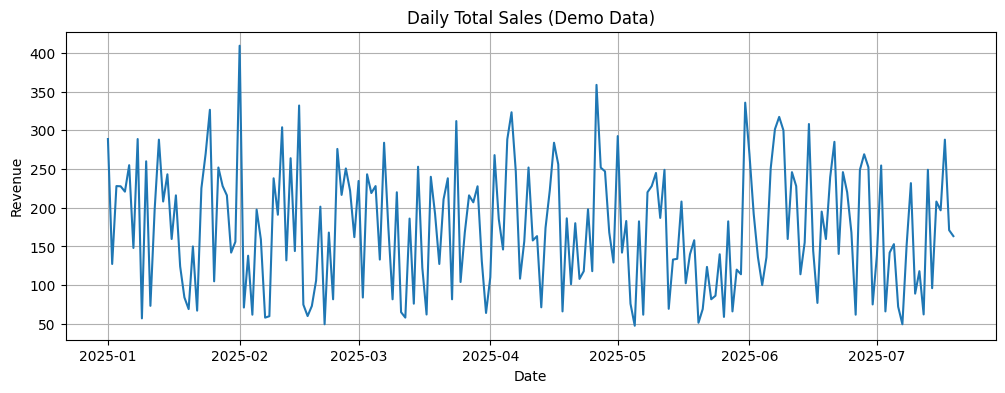

In [21]:
# Prepare daily total sales from demo data
daily_demo = df_demo.groupby("date", as_index=False)["amount"].sum()

plt.figure(figsize=(12,4))
plt.plot(daily_demo["date"], daily_demo["amount"])
plt.title("Daily Total Sales (Demo Data)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

### Matplotlib Subplots (2x2)

แนวคิด: EDA เร็ว ๆ โดยมองหลายมุมในภาพเดียว

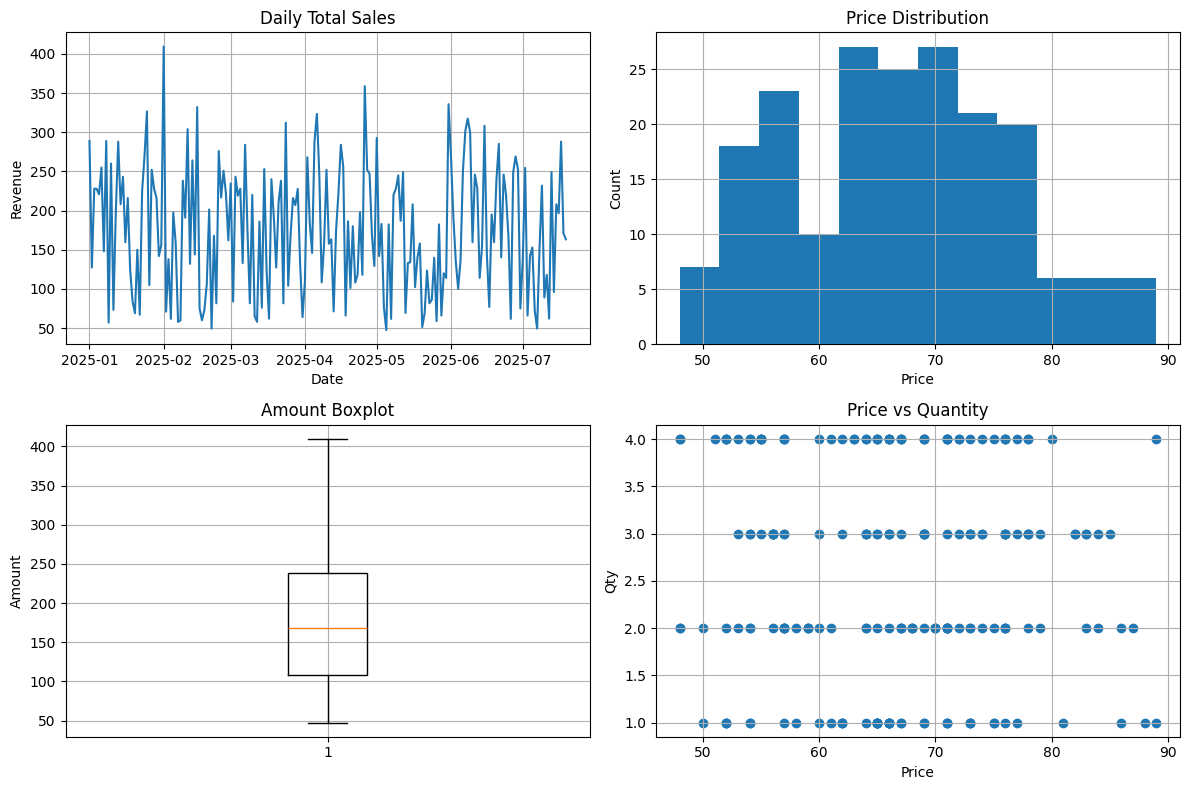

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (1) Line: trend
axes[0, 0].plot(daily_demo["date"], daily_demo["amount"])
axes[0, 0].set_title("Daily Total Sales")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].grid(True)

# (2) Histogram: price distribution (dropna)
axes[0, 1].hist(df_demo["price"].dropna(), bins=12)
axes[0, 1].set_title("Price Distribution")
axes[0, 1].set_xlabel("Price")
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(True)

# (3) Boxplot: amount spread
axes[1, 0].boxplot(df_demo["amount"])
axes[1, 0].set_title("Amount Boxplot")
axes[1, 0].set_ylabel("Amount")
axes[1, 0].grid(True)

# (4) Scatter: price vs qty
axes[1, 1].scatter(df_demo["price"], df_demo["qty"])
axes[1, 1].set_title("Price vs Quantity")
axes[1, 1].set_xlabel("Price")
axes[1, 1].set_ylabel("Qty")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

## 6.2 seaborn (Statistical EDA)

จุดเด่น:
- ทำกราฟเชิงสถิติได้เร็ว (distribution/relationship)  
- ทำงานกับ DataFrame โดยตรง  
- ใช้เพื่อ “หา pattern” ก่อนทำโมเดล

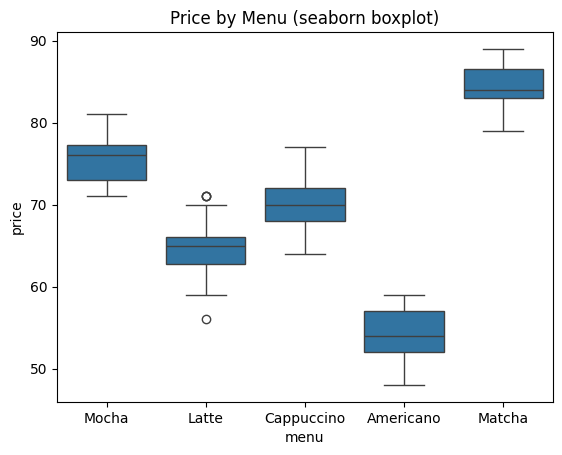

In [23]:
sns.boxplot(x="menu", y="price", data=df_demo)
plt.title("Price by Menu (seaborn boxplot)")
plt.show()

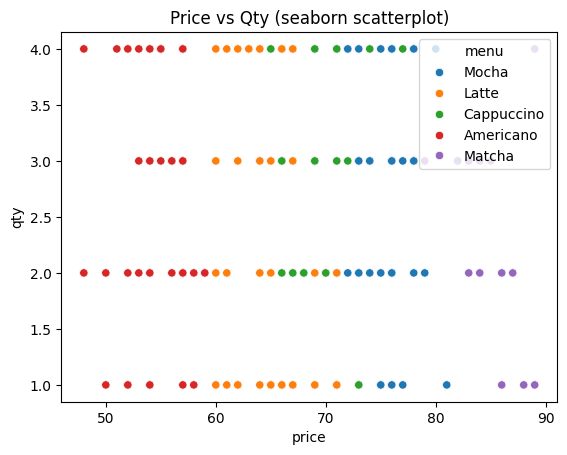

In [24]:
sns.scatterplot(x="price", y="qty", hue="menu", data=df_demo)
plt.title("Price vs Qty (seaborn scatterplot)")
plt.show()

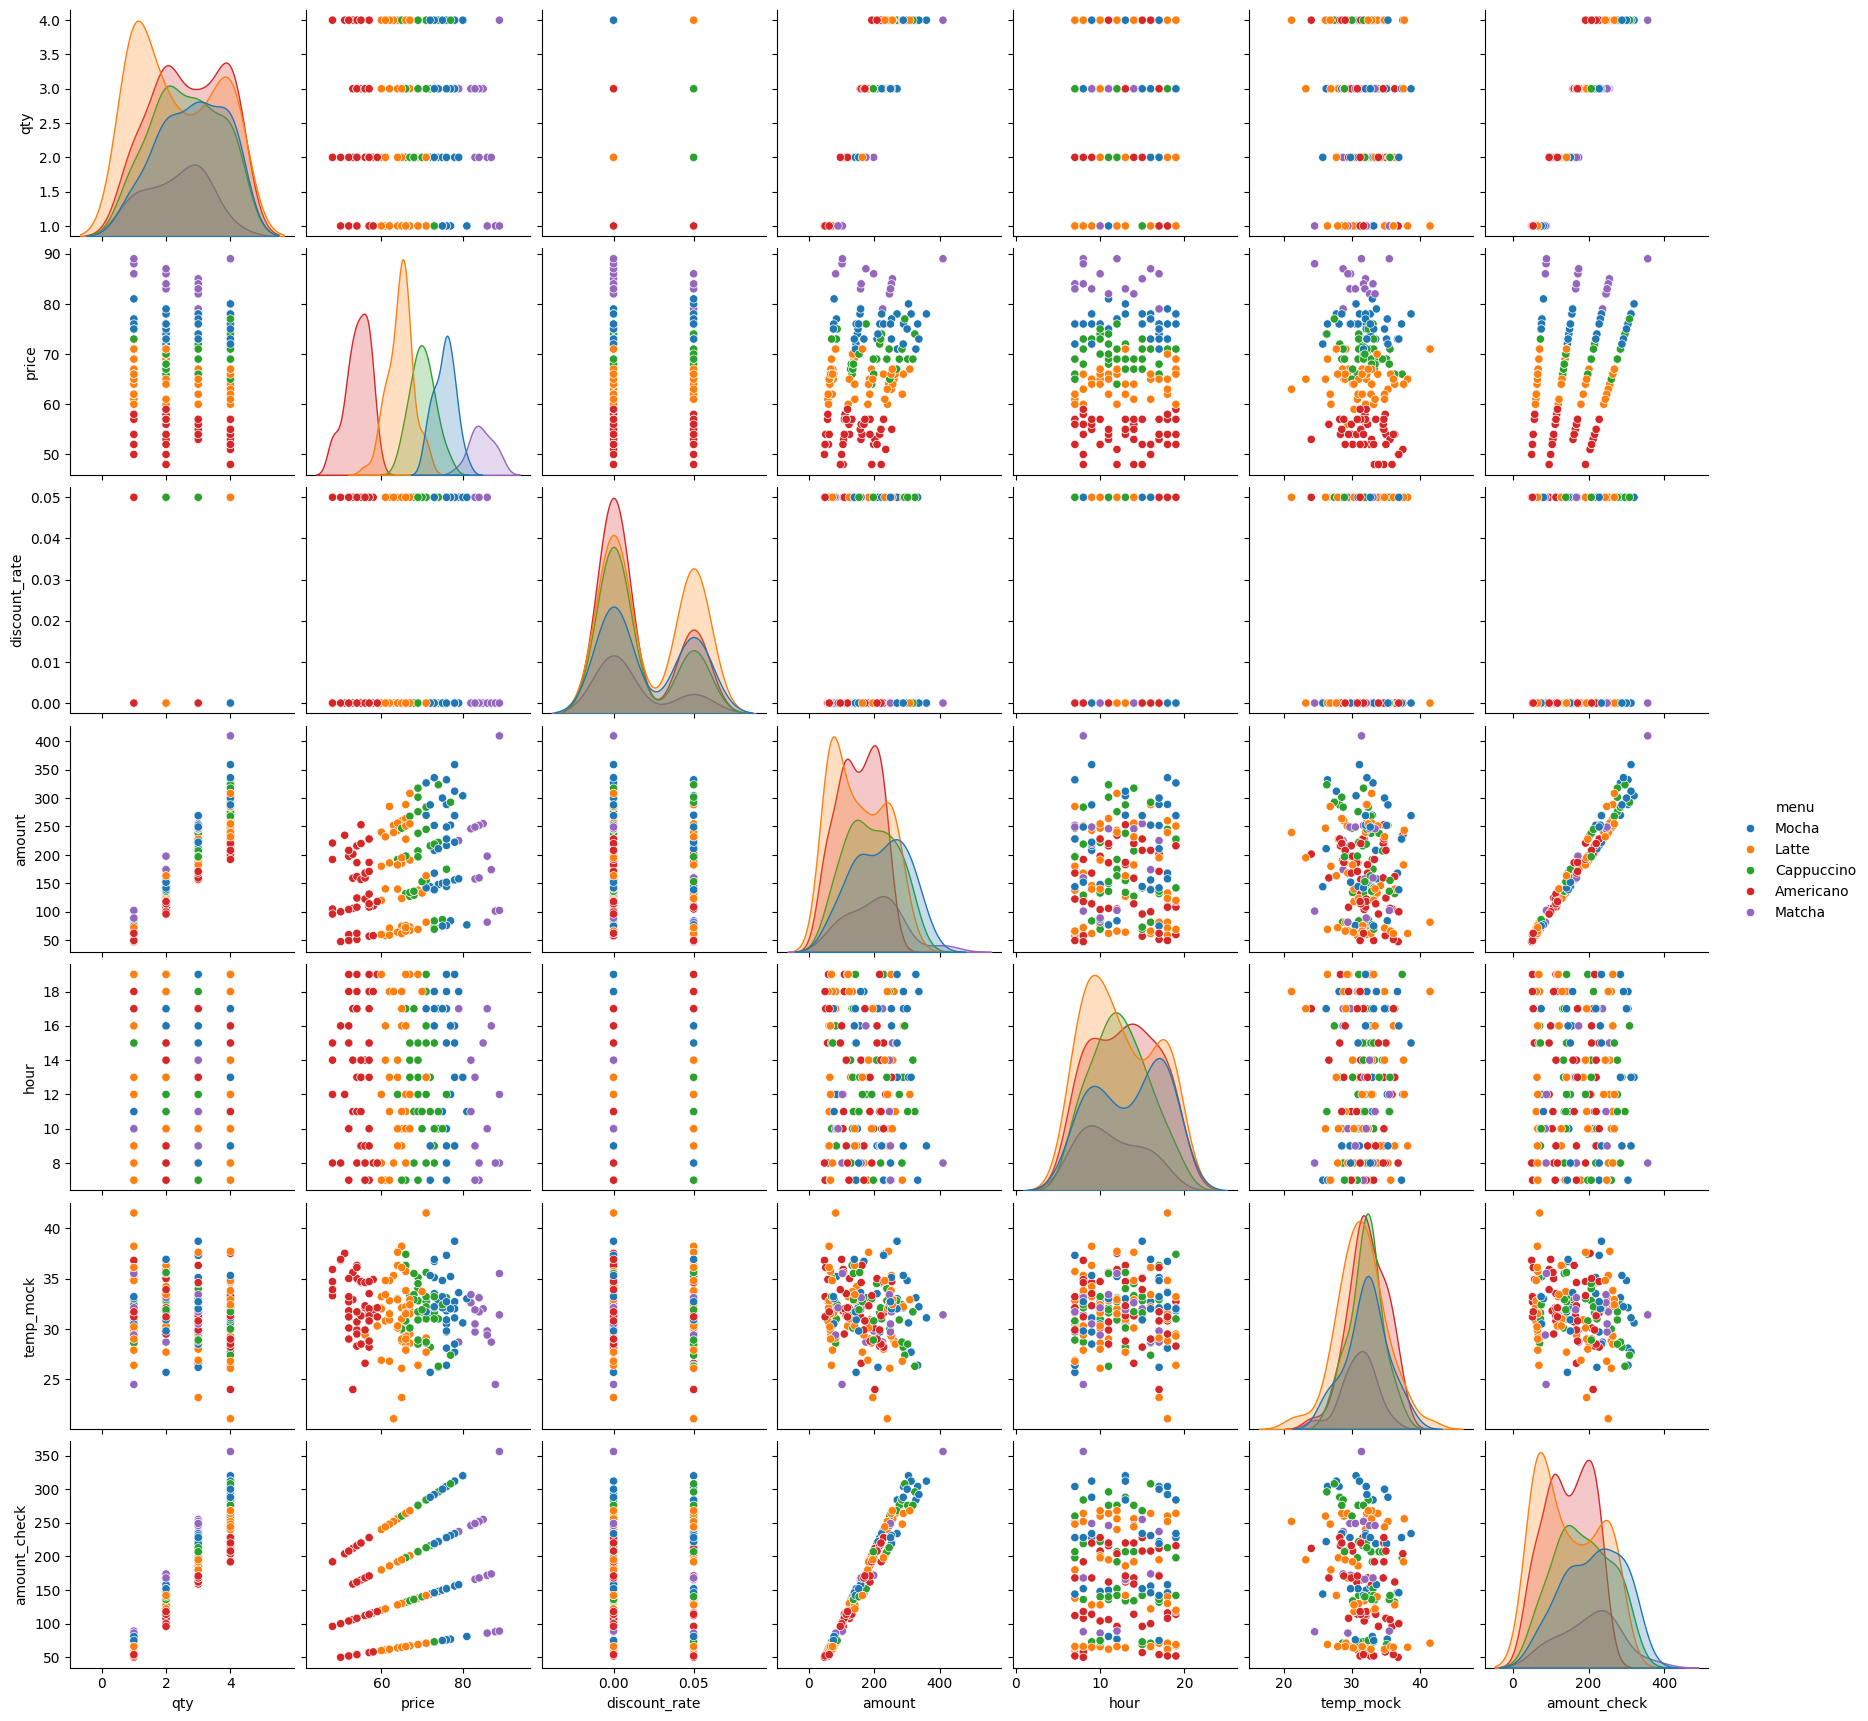

In [25]:
sns.pairplot(df_demo, hue="menu")
plt.show()

## 6.3 Plotly (Interactive + 3D)

จุดเด่น:
- hover/zoom/rotate (เข้าใจค่าแต่ละจุดได้ทันที)
- เหมาะกับการสื่อสาร/เดโม/ทำแอป

In [26]:
fig = px.line(daily_demo, x="date", y="amount", title="Interactive Line: Daily Total Sales (Plotly)", width=1000)
fig.show()

### Plotly 3D Scatter

มองความสัมพันธ์ 3 ตัวแปรพร้อมกัน โดยใช้สี/สัญลักษณ์ช่วยแยกกลุ่ม

In [27]:
df_demo_plot = df_demo.dropna(subset=["price"])

fig = px.scatter_3d(
    df_demo_plot,
    x="price",
    y="qty",
    z="amount",
    color="menu",
    symbol="customer_type",
    title="3D View (Demo): Price vs Quantity vs Amount",
    width=1000,
    height=800
)
fig.show()

---

# 7) Lab: PM2.5 Time Series (2021–2024)

เป้าหมายคือรวมข้อมูลหลายปีให้เป็น time-series เดียว แล้วสำรวจแนวโน้มระยะยาวด้วยสถิติและ visualization พื้นฐาน

**Dataset:** PM2.5 (2021–2024)  
- `pm2.52021.csv`  
- `pm2.52022.csv`  
- `pm2.52023.csv`  
- `pm2.52024.csv`

โครงสร้าง (ทุกไฟล์เหมือนกัน):
- `Date` : วันที่
- คอลัมน์สถานีวัด (station codes) เช่น `54T`, `03T`, `A13`, …

## 7.1 Load Data (Multiple Files)
### Step 1: Upload CSV files (Colab)

รัน cell นี้ใน Colab เพื่ออัปโหลดไฟล์ทั้ง 4 ปี

In [28]:
from google.colab import files
uploaded = files.upload()
uploaded.keys()

Saving pm2.52021.csv to pm2.52021.csv
Saving pm2.52022.csv to pm2.52022.csv
Saving pm2.52023.csv to pm2.52023.csv
Saving pm2.52024.csv to pm2.52024.csv


dict_keys(['pm2.52021.csv', 'pm2.52022.csv', 'pm2.52023.csv', 'pm2.52024.csv'])

### Step 2: Read CSV files

In [29]:
df_2021 = pd.read_csv("pm2.52021.csv")
df_2022 = pd.read_csv("pm2.52022.csv")
df_2023 = pd.read_csv("pm2.52023.csv")
df_2024 = pd.read_csv("pm2.52024.csv")

df_2021.head()

,Date,02T,05T,10T,11T,12T,59T,61T,03T,50T,...,92T,42T,43T,44T,62T,63T,78T,80T,89T,93T
0,1/1/2021,27.0,20,22.0,25,22.0,20,25.0,24.0,25.0,...,NaN,19.0,23.0,20,18,17,7.0,18.0,17.0,NaN
1,1/2/2021,32.0,25,26.0,27,27.0,23,26.0,29.0,31.0,...,NaN,19.0,24.0,16,15,19,8.0,13.0,17.0,NaN
2,1/3/2021,46.0,37,33.0,41,40.0,38,29.0,44.0,44.0,...,NaN,22.0,27.0,15,15,18,6.0,12.0,15.0,NaN
3,1/4/2021,39.0,31,32.0,36,38.0,36,28.0,46.0,41.0,...,NaN,23.0,27.0,12,12,12,3.0,9.0,17.0,NaN
4,1/5/2021,50.0,31,31.0,32,44.0,28,24.0,67.0,41.0,...,NaN,19.0,27.0,14,8,13,3.0,11.0,14.0,NaN


### Step 3: Convert Date column to datetime

แนวคิด: time-series ต้องให้ `Date` เป็นชนิด datetime เพื่อใช้ `sort`, `resample`, `dt.year` ได้

In [30]:
for df in [df_2021, df_2022, df_2023]:
    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
df_2024["Date"] = pd.to_datetime(df_2024["Date"], format="%d/%m/%Y")

In [31]:
df_2021["Date"]

,Date
0,2021-01-01
1,2021-01-02
2,2021-01-03
3,2021-01-04
4,2021-01-05
...,...
360,2021-12-27
361,2021-12-28
362,2021-12-29
363,2021-12-30


## 7.2 Combine DataFrames into one time-series

In [32]:
df_all = pd.concat([df_2021, df_2022, df_2023, df_2024], axis=0, ignore_index=True)
df_all = df_all.sort_values("Date").reset_index(drop=True)

df_all.shape, df_all.head(), df_all.tail()

((1277, 99),
         Date   02T   05T   10T   11T   12T   59T   61T   03T   50T  ...  72T  \
 0 2021-01-01  27.0  20.0  22.0  25.0  22.0  20.0  25.0  24.0  25.0  ...  NaN   
 1 2021-01-02  32.0  25.0  26.0  27.0  27.0  23.0  26.0  29.0  31.0  ...  NaN   
 2 2021-01-03  46.0  37.0  33.0  41.0  40.0  38.0  29.0  44.0  44.0  ...  NaN   
 3 2021-01-04  39.0  31.0  32.0  36.0  38.0  36.0  28.0  46.0  41.0  ...  NaN   
 4 2021-01-05  50.0  31.0  31.0  32.0  44.0  28.0  24.0  67.0  41.0  ...  NaN   
 
    104T  106T  107T  108T  109T  110T  111T  112T  105T  
 0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
 1   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
 2   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
 3   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
 4   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
 
 [5 rows x 99 columns],
            Date   02T   05T   10T   11T   12T   59T   61T   03T   50T  ...  \
 1272 2024-12-27  47.4  35.4  35.8  35.4

### Check structure

ให้ดู:
- จำนวนแถวสัมพันธ์กับจำนวนปีหรือไม่
- โครงสร้างคอลัมน์เปลี่ยนไปหรือไม่หลังรวมข้อมูล

In [33]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1277 entries, 0 to 1276
Data columns (total 99 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1277 non-null   datetime64[ns]
 1   02T        1269 non-null   float64       
 2   05T        1258 non-null   float64       
 3   10T        1229 non-null   float64       
 4   11T        1230 non-null   float64       
 5   12T        1235 non-null   float64       
 6   59T        1275 non-null   float64       
 7   61T        1221 non-null   float64       
 8   03T        1256 non-null   float64       
 9   50T        1230 non-null   float64       
 10  52T        1267 non-null   float64       
 11  53T        1205 non-null   float64       
 12  54T        1273 non-null   float64       
 13  08T        1225 non-null   float64       
 14  16T        1152 non-null   float64       
 15  17T        1270 non-null   float64       
 16  18T        1266 non-null   float64       


In [34]:
for col in df_all.columns[1:]:
  if df_all[col].isna().sum() == 0:
    print(col) # ไม่มี

---

## 7.3 pandas vs NumPy & Vectorized Operations

เราจะเลือก “สถานีวัด” หนึ่งสถานีเพื่อวิเคราะห์ แล้วเปรียบเทียบการทำงานบน pandas กับ NumPy

### Step 1: Select a station

เลือกสถานี เช่น `54T` (ปรับได้)

In [35]:
station = "54T"
station

'54T'

### Step 2: pandas Series vs DataFrame

In [36]:
pm_series = df_all[station]
pm_df = df_all[["Date", station]]

type(pm_series), type(pm_df)

(pandas.core.series.Series, pandas.core.frame.DataFrame)

### Step 3: Convert to NumPy array

แนวคิด: pandas ทำงานบน NumPy array อยู่ข้างใต้  
เมื่ออยากทำ numeric computation แบบตรง ๆ อาจใช้ NumPy ได้สะดวก

In [37]:
pm_values = pm_series.to_numpy()
type(pm_values), pm_values[:10]

(numpy.ndarray, array([28., 33., 47., 55., 42., 47., 38., 30., 24., 33.]))

### Step 4: Descriptive statistics (NumPy vs pandas)

In [38]:
np.mean(np.array([1, 2, 3, 4, np.nan])) # เอา NaN มารวมมันกลายเป็น NaN หมด

np.float64(nan)

In [39]:
np.nanmean(np.array([1, 2, 3, 4, np.nan])) # วิธี bypass NaN คือใส่ nan หน้าค่าสถิติ

np.float64(2.5)

In [40]:
np.nanmean(pm_values), np.nanmedian(pm_values), np.nanmin(pm_values), np.nanmax(pm_values)

(np.float64(32.174391201885314),
 np.float64(29.0),
 np.float64(12.4),
 np.float64(106.0))

In [41]:
pm_series.describe()

,54T
count,1273.000000
mean,32.174391
std,13.316635
min,12.400000
25%,22.000000
50%,29.000000
75%,38.500000
max,106.000000


### Step 5: Boolean mask + vectorized operation

ตัวอย่าง: นับจำนวนวันที่ PM2.5 สูงกว่า 50 µg/m³ โดยไม่ใช้ loop

In [42]:
high_pm_mask = pm_values > 50
np.sum(high_pm_mask)

np.int64(125)

### Step 6: 90th percentile (สำคัญตาม Lab)

- คำนวณ p90 ด้วย NumPy  
- นับจำนวนวันที่สูงกว่า p90

In [43]:
p90 = np.nanpercentile(pm_values, 90)
p90, np.sum(pm_values > p90)

(np.float64(50.0), np.int64(125))

---

## 7.4 Basic Visualization (Long-Term Trend)

### Step 1: Line plot แนวโน้ม 4 ปี

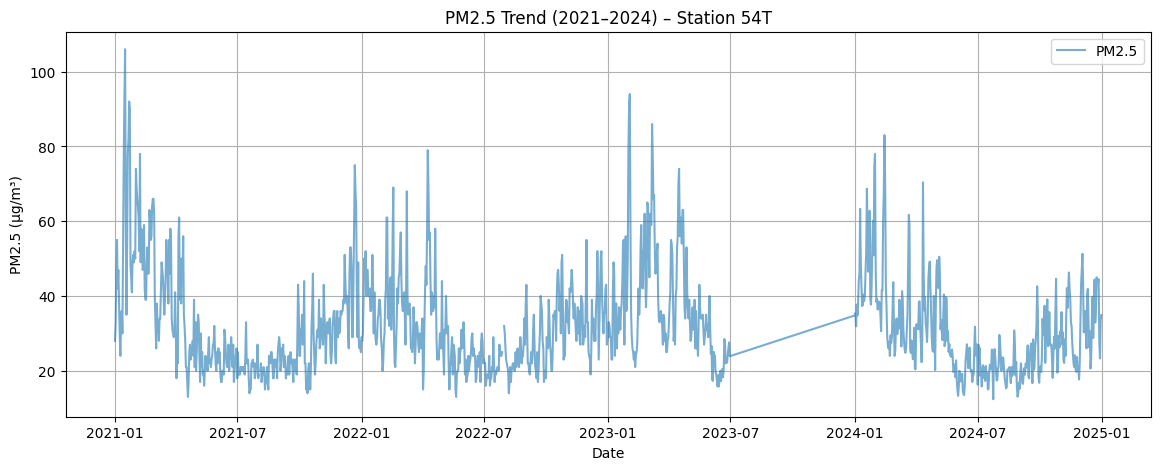

In [44]:
plt.figure(figsize=(14,5))
plt.plot(df_all["Date"], pm_values, alpha=0.6, label="PM2.5")
plt.title(f"PM2.5 Trend (2021–2024) – Station {station}")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.grid(True)
plt.legend()
plt.show()

### Step 2: Add 90th percentile threshold line

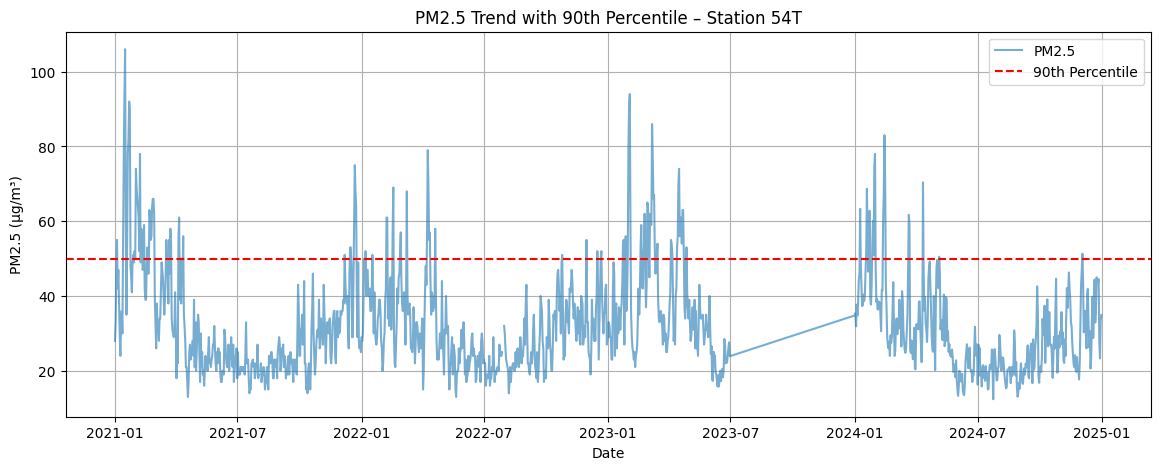

In [45]:
plt.figure(figsize=(14,5))
plt.plot(df_all["Date"], pm_values, alpha=0.6, label="PM2.5")

plt.axhline(y=p90, linestyle="--", color="red", label="90th Percentile")

plt.title(f"PM2.5 Trend with 90th Percentile – Station {station}")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(True)
plt.show()

### Step 3: Yearly aggregation (time-based analysis)

เพิ่มคอลัมน์ `Year` แล้วสรุปค่าเฉลี่ยรายปี

In [46]:
df_all["Year"] = df_all["Date"].dt.year
df_all.groupby("Year")[station].mean()

,54T
Year,
2021,32.586777
2022,30.936639
2023,37.975691
2024,30.124044


---

# 8) Mini Tasks (Hands-on)

ทำใน Notebook นี้ (เขียนโค้ดเอง) แล้วแสดงผลลัพธ์

**Task 1**: ใช้ NumPy คำนวณ 75th percentile และ 95th percentile  
**Task 2**: เปรียบเทียบจำนวนวันที่ PM2.5  
- > 90th percentile  
- > 95th percentile  

**Task 3**: ใช้ pandas และ NumPy คำนวณค่าเฉลี่ย PM2.5 แล้วเปรียบเทียบผลลัพธ์ (ควรได้ค่าเดียวกันหรือใกล้เคียง)  
**Task 4**: เปลี่ยนสถานีวัด แล้ววิเคราะห์ว่า  
- แนวโน้มระยะยาวแตกต่างกันหรือไม่  
- ค่าใน upper tail แตกต่างกันอย่างไร

> คำแนะนำ: สำหรับ Task 4 ให้เลือกอย่างน้อย 2 สถานี แล้วเขียนสรุปเปรียบเทียบ

In [47]:
# Task 1: 75th and 95th percentile (write your code here)
p75 = np.nanpercentile(pm_values, 75)
p95 = np.nanpercentile(pm_values, 95)

print("75th percentile =", p75)
print("95th percentile =", p95)

75th percentile = 38.5
95th percentile = 59.0


In [48]:
# Task 2: count days above thresholds (write your code here)
count_above_p90 = np.sum(pm_values > p90)
count_above_p95 = np.sum(pm_values > p95)

print("Days above 90 =", count_above_p90)
print("Days above 95 =", count_above_p95)

Days above 90 = 125
Days above 95 = 61


In [49]:
# Task 3: compare mean from NumPy vs pandas (write your code here)
mean_np = np.nanmean(pm_values)
mean_pd = pm_series.describe().loc["mean"]

print("Mean by NumPy =", mean_np)
print("Mean by pandas =", mean_pd)

Mean by NumPy = 32.174391201885314
Mean by pandas = 32.174391201885314


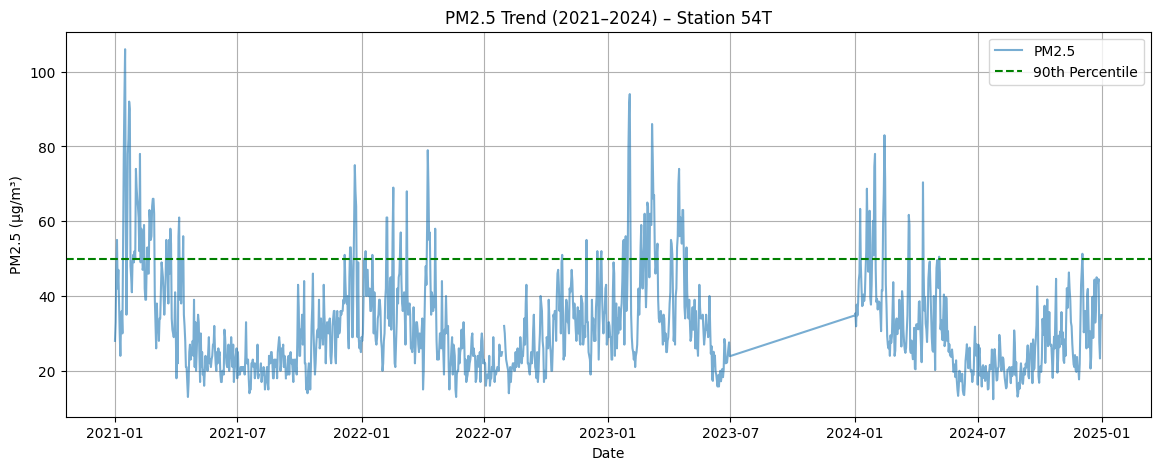

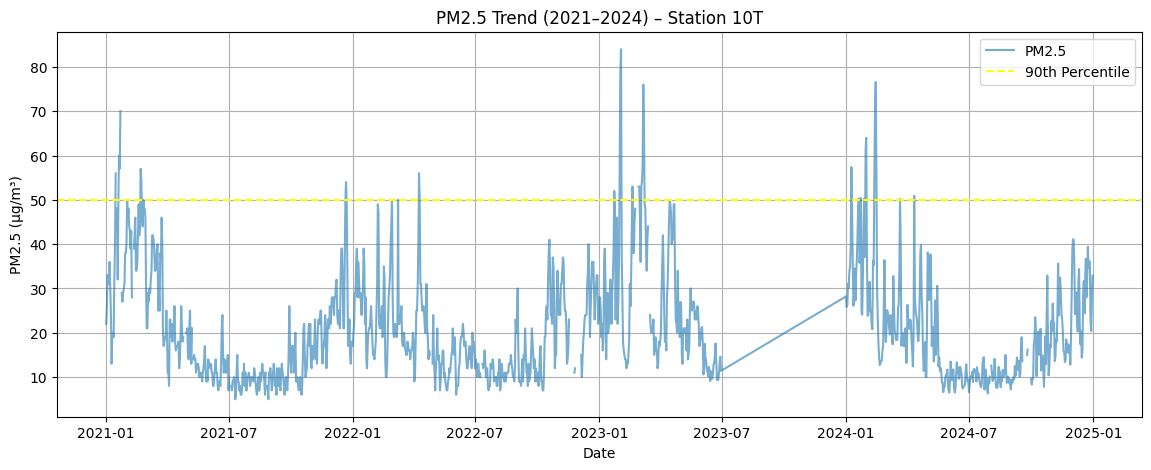

In [51]:
# Task 4: change station and analyze (write your code here)
station2 = "10T"

pm_series2 = df_all[station2]
pm_values2 = pm_series2.to_numpy()

plt.figure(figsize=(14,5)) # สถานี 54T
plt.plot(df_all["Date"], pm_values, alpha=0.6, label="PM2.5")
plt.axhline(y=p90, linestyle="--", color="green", label="90th Percentile")
plt.title(f"PM2.5 Trend (2021–2024) – Station {station}")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14,5)) # สถานี 54T
plt.plot(df_all["Date"], pm_values2, alpha=0.6, label="PM2.5")
plt.axhline(y=p90, linestyle="--", color="yellow", label="90th Percentile")
plt.title(f"PM2.5 Trend (2021–2024) – Station {station2}")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.grid(True)
plt.legend()
plt.show()


# แนวโน้มระยะยาวแตกต่างกันหรือไม่
# แนวโน้มระยะยาวเหมือนกัน กราฟสูงต้นปี ต่ำกลางปี แต่สถานี 54T มีระดับฝุ่นสูงกว่า 10T

# ค่าใน upper tail แตกต่างกันอย่างไร
# สถานี 54T มีจำนวนฝุ่นในช่วงวิกฤตที่รุนแรงกว่าสถานี 10T และมีค่าที่พุ่งเกินเส้น Percentile เยอะกว่า

---

# 9) Summary Reflection (Student Reflection)

ให้นักศึกษาสรุปผลใน Notebook (เขียนเป็นข้อความ)

1. แนวโน้ม PM2.5 ระยะยาว (2021–2024) เป็นอย่างไร  
**ตอบ** ทั้งสองสถานี ช่วงครึ่งปีแรกกราฟค่าฝุ่นของสถานีจะมีลักษณะพุ่งสูงมากกว่าช่วงครึ่งปีหลัง
2. ปีใดมีค่าฝุ่นเฉลี่ยสูงที่สุด และมีข้อสังเกตใด  
**ตอบ** ปี 2023 ดูจากการมี PM2.5 มากที่สุดในกราฟ
3. Percentile ให้มุมมองข้อมูลต่างจากค่าเฉลี่ยอย่างไร  
**ตอบ** ค่าเฉลี่ยจะแสดงให้เห็นแค่ค่าตรงกลาง เราอาจไม่ทราบค่าที่แย่ที่สุดหรือดีที่สุดได้จาการดูค่าเฉลี่ย แต่ Percentile จะแสดงให้เห็นการกระจายตัวของข้อมูลและดูข้อมูลแบบ Extreme ได้
4. NumPy มีบทบาทอย่างไรเมื่อเทียบกับ pandas  
**ตอบ** NumPy ประมวลผลคำสั่งด้วยความเร็ว แต่ pandas จะเน้นจัดการข้อมูลและคำนวณโดยตรง
5. สิ่งสำคัญที่สุดที่ได้เรียนรู้จาก Lab 2 นี้
**ตอบ** คำสั่ง NumPy และ pandas ต่างๆ

> ส่วนนี้สามารถคัดลอกไปใช้ในรายงานตามกรอบ CRISP-DM ได้ในภายหลัง

---

# 10) Deliverable Checklist

ก่อนส่งงาน โปรดตรวจสอบว่า:

- [ ] Notebook รันได้ครบทุก cell และไม่มี error  
- [ ] มีการรวมข้อมูล 2021–2024 เป็น time-series เดียว (`df_all`)  
- [ ] เลือกอย่างน้อย 1 สถานีและแสดงแนวโน้ม + 90th percentile  
- [ ] ทำ Mini Tasks ครบ (Task 1–4)  
- [ ] เขียน Summary Reflection ครบทุกข้อ  
- [ ] Download .ipynb ตั้งชื่อไฟล์ *[รหัสนักศึกษา]_Lab2.ipynb*
- [ ] ส่งใน **งานในชั้นเรียน > "Lab 2"**